# Tugas Proyek IF3211 - Domain-Specific Computation
## Deteksi Transisi Respirasi Aerobik-Anaerobik Berdasarkan Respiratory Exchange Ratio (RER) Menggunakan Arsitektur Long Short-Term Memory (LSTM)

**Anggota Kelompok:**
* 18223012 - Wilson
* 18223020 - Brandon Theodore Ferrinov
* 18223038 - Rafli Dwi Nugraga
* 18223090 - Derick Amadeus Budiono


Sumber Dataset : http://physionet.org/content/treadmill-exercise-cardioresp/1.0.1/

# 1. ***Library Import***

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

print("Modul berhasil diimpor!")

Modul berhasil diimpor!


# ***2. Data Loading***

In [13]:
# 1. Muat dataset test_measure 
df = pd.read_csv('datasets/test_measure.csv')

# 2. Ganti filter ID_test menggunakan format string yang sesuai (misal: '2_1')
df_subject = df[df['ID_test'] == '2_1'].copy()

# 3. Hitung Respiratory Exchange Ratio (RER)
df_subject['RER'] = df_subject['VCO2'] / df_subject['VO2']

# 4. Pelabelan Target (0 = Aerobik, 1 = Anaerobik)
# Menghindari error pandas SettingWithCopyWarning, kita gunakan .loc atau pastikan dari awal sudah di-.copy()
df_subject['Anaerobic_Label'] = (df_subject['RER'] >= 1.0).astype(int)

# Tampilkan 5 data teratas untuk memastikan fitur target sudah terbentuk
print(df_subject[['time', 'HR', 'VO2', 'VCO2', 'RER', 'Anaerobic_Label']])

     time     HR     VO2    VCO2       RER  Anaerobic_Label
0       0   63.0   478.0   360.0  0.753138                0
1       2   75.0   401.0   295.0  0.735661                0
2       4   82.0   449.0   319.0  0.710468                0
3       7   87.0   461.0   340.0  0.737527                0
4       9   92.0   574.0   417.0  0.726481                0
..    ...    ...     ...     ...       ...              ...
597  1038  120.0  1308.0  1558.0  1.191131                1
598  1040  120.0  1314.0  1541.0  1.172755                1
599  1042  121.0  1286.0  1504.0  1.169518                1
600  1044  121.0  1325.0  1546.0  1.166792                1
601  1046  121.0  1255.0  1469.0  1.170518                1

[602 rows x 6 columns]


## **3. Data Understanding**

## **4. Pra-pemrosesan Data (Scaling)**

In [14]:
# Pilih fitur yang akan digunakan sebagai input (X)
features = ['HR', 'VO2', 'VCO2', 'VE', 'Speed']
data_X = df_subject[features].values
data_Y = df_subject['Anaerobic_Label'].values

# Inisialisasi Scaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_X_scaled = scaler.fit_transform(data_X)

print(f"Bentuk data X setelah di-scale: {data_X_scaled.shape}")

Bentuk data X setelah di-scale: (602, 5)


## **5. Pembuatan Sekuens Waktu (Sliding Window)**

In [15]:
def create_sequences(X, y, time_steps=10):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        # Ambil data dari indeks i hingga i + time_steps
        Xs.append(X[i:(i + time_steps)])
        # Target adalah label pada langkah waktu setelah jendela tersebut
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 10 # Model akan melihat 10 langkah waktu ke belakang

X_seq, y_seq = create_sequences(data_X_scaled, data_Y, TIME_STEPS)

# Split sekuensial untuk time-series (80% training, 20% testing)
# Ingat: Time-series TIDAK BOLEH di-random split agar urutan waktu tidak rusak!
split_idx = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (473, 10, 5), y_train shape: (473,)
X_test shape: (119, 10, 5), y_test shape: (119,)


## **6. Arsitektur LSTM**

In [16]:
# Inisialisasi Model Sequential
model = Sequential()

# Layer LSTM Pertama
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Untuk mencegah overfitting

# Layer LSTM Kedua
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Layer Output (Dense)
# Memakai aktivasi 'sigmoid' karena ini adalah masalah klasifikasi biner (0 atau 1)
model.add(Dense(units=1, activation='sigmoid'))

# Kompilasi Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Ringkasan Arsitektur
model.summary()

# Latih Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    shuffle=False # Ingat, time-series tidak boleh di-shuffle
)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_2 (LSTM)               (None, 10, 50)            11200     
                                                                 
 dropout_2 (Dropout)         (None, 10, 50)            0         
                                                                 
 lstm_3 (LSTM)               (None, 50)                20200     
                                                                 
 dropout_3 (Dropout)         (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 31451 (122.86 KB)
Trainable params: 31451 (122.86 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
27/27

## **7. Evaluasi dan Visualisasi**

4/4 [==============================] - 1s 3ms/step - loss: nan - accuracy: 0.1008
Akurasi Test: 10.08%


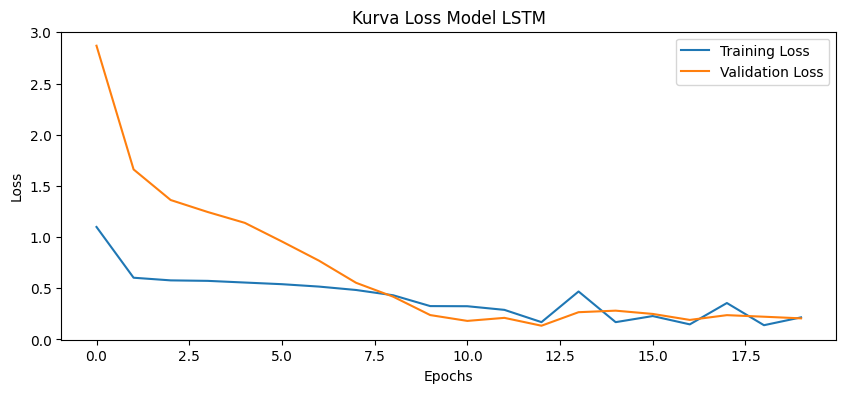

4/4 [==============================] - 1s 3ms/step


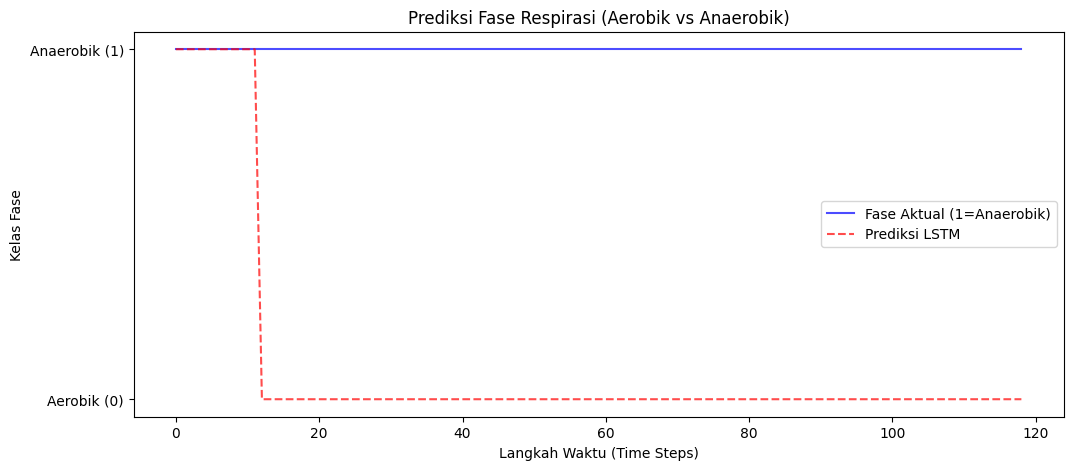

In [17]:
# Evaluasi pada data uji
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Akurasi Test: {accuracy * 100:.2f}%")

# Plot Riwayat Pelatihan (Loss)
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kurva Loss Model LSTM')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot Prediksi vs Aktual
y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

plt.figure(figsize=(12, 5))
plt.plot(y_test, label='Fase Aktual (1=Anaerobik)', color='blue', alpha=0.7)
plt.plot(y_pred_binary, label='Prediksi LSTM', color='red', linestyle='--', alpha=0.7)
plt.title('Prediksi Fase Respirasi (Aerobik vs Anaerobik)')
plt.xlabel('Langkah Waktu (Time Steps)')
plt.ylabel('Kelas Fase')
plt.yticks([0, 1], ['Aerobik (0)', 'Anaerobik (1)'])
plt.legend()
plt.show()